In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
class Value:
    def __init__(self,data,_children=(),_op = '',label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None 
        self._prev = _children
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data = {self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)   #used for operations including an int and a Value obj like Value(4)+1
        out = Value(self.data + other.data, {self,other}, '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad 
        out._backward = _backward
        return out 

    def __radd__(self, other):
        return self + other

    def __mul__(self,other):  # works for Value * int but not for int * value as it is value.__mul__(int) thus rmul is used 
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, {self,other}, '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other,(int, float)) , "pow supported types : int and float only"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad+= other * (self.data ** (other-1)) *out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self,other): #works for swapping the Value with int and thus perform Value.__mul__(int) instead of int.__mul__(val)
        return self * other 

    def __truediv__(self,other):
        return self * other**-1   # (a/b = a * b**-1) 

    def __neg__(self):
        return self * -1

    def __sub__(self,other):
        return self + (-other)
    
    def __rsub__(self,other):
        return other + (-self)
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
        out = Value(t, {self,}, 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):  # for e^x
        x= self.data
        out = Value(math.exp(x), (self,) , 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


In [9]:
from graphviz import Digraph
#toposort for proper u to v relation where u comes before v depicting proper computation of the gradients
def trace(root):
    #build the node and edges of the graph
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format = 'svg',graph_attr={'rankdir':'LR'})
    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #rectangular node for data
        dot.node(name= uid , label = "{%s | data %.4f | grad %.4f}" % (n.label ,n.data,n.grad,), shape= 'record')
        if n._op:
            #value after operation node
            dot.node(name =uid+ n._op, label = n._op)
            dot.edge(uid+ n._op,uid)
    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    return dot

In [10]:
#inputs x1,x2
x1 = Value(2.0 , label = 'x1')
x2 = Value(0.0 , label = 'x2')
#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.8813735870195432, label = 'b')
#x1w1 + x2w2 +b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


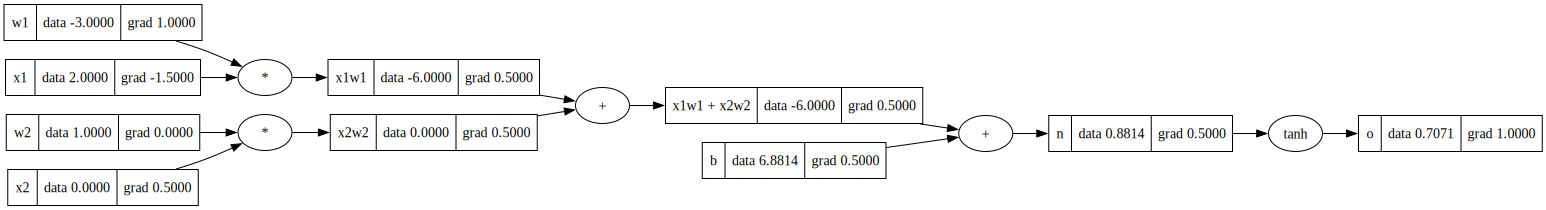

In [11]:
o.backward()
draw_dot(o)

In [12]:
#inputs x1,x2
x1 = Value(2.0 , label = 'x1')
x2 = Value(0.0 , label = 'x2')
#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.8813735870195432, label = 'b')
#x1w1 + x2w2 +b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
#expanding tanh   -> ((e**2x) -1) / ((e**2x) +1)
e = (2*n).exp()
o = (e-1)/(e+1)
#--------------
o.label = 'o'
o.backward()


In [24]:
import random  
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    #forward pass
    def __call__(self,x):
        act = sum((wi*xi for wi , xi in zip(self.w, x)),self.b)  # acivation funciton 
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
    
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())
        return params

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] +nouts
        self.layers =[Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        
    

In [25]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data = -0.6129692183796197)

In [26]:
xs = [[2.0,3.0,-1.0],
      [3.0,-1.0,0.5],
      [0.5,1.0,1.0],
      [1.0,1.0,-1.0]]
ys = [1.0,-1.0,-1.0,1.0] # desired output for the above inputs

In [ ]:
for k in range(25):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))
    
    #backward pass
    loss.backward()

    #update the weights and biases using gradient descent
    for p in n.parameters():
        p.grad = 0.0  # reset the gradients to zero after each update(.zero_grad)
        p.data -= 0.05 * p.grad

    print(k, loss.data)


0 3.943989904553238e-16
1 1.6150350845611356e-15
2 1.0344815450059814e-14
3 9.468985129749746e-14
4 1.1014882507267325e-12
5 1.4291438081235884e-11
6 1.8262069588869636e-10
7 2.0757585199727497e-09
8 1.9574951555624043e-08
9 1.4774826392323196e-07
10 8.865326347656459e-07
11 4.290517185642098e-06
12 1.7209660678847545e-05
13 5.905491444291835e-05
14 0.00017823661038652265
15 0.0004785431614579451
16 0.0011114991243918989
17 0.0020168720846804084
18 0.002406573538771781
19 0.0017335160060377073
20 0.0008581346255492447
21 0.00034969001317528995
22 0.00013080517603022006
23 4.716989727063325e-05
24 1.673644425011389e-05


In [31]:
ypred

[Value(data = 1.0),
 Value(data = -1.0),
 Value(data = -1.0),
 Value(data = 0.9959089800477003)]